<a href="https://colab.research.google.com/github/rudrakshmala/supply-chain-analysis/blob/main/supply_chain_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import io

uploaded = files.upload()
filename = list(uploaded.keys())[0]
print("✅ Uploaded:", filename)

Saving supply_chain_data.csv to supply_chain_data.csv
✅ Uploaded: supply_chain_data.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style("whitegrid")

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [3]:
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
df.head()

Shape: (100, 24)

Columns:
 ['Product type', 'SKU', 'Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Customer demographics', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Inspection results', 'Defect rates', 'Transportation modes', 'Routes', 'Costs']

Missing Values:
 Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufact

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [4]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Fill or drop nulls
df.dropna(inplace=True)

# Standardize column names
df.columns = df.columns.str.strip().str.replace(' ', '_')

print("✅ Cleaned Shape:", df.shape)
df.head()

✅ Cleaned Shape: (100, 24)


,Product_type,SKU,Price,Availability,Number_of_products_sold,Revenue_generated,Customer_demographics,Stock_levels,Lead_times,Order_quantities,...,Location,Lead_time,Production_volumes,Manufacturing_lead_time,Manufacturing_costs,Inspection_results,Defect_rates,Transportation_modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


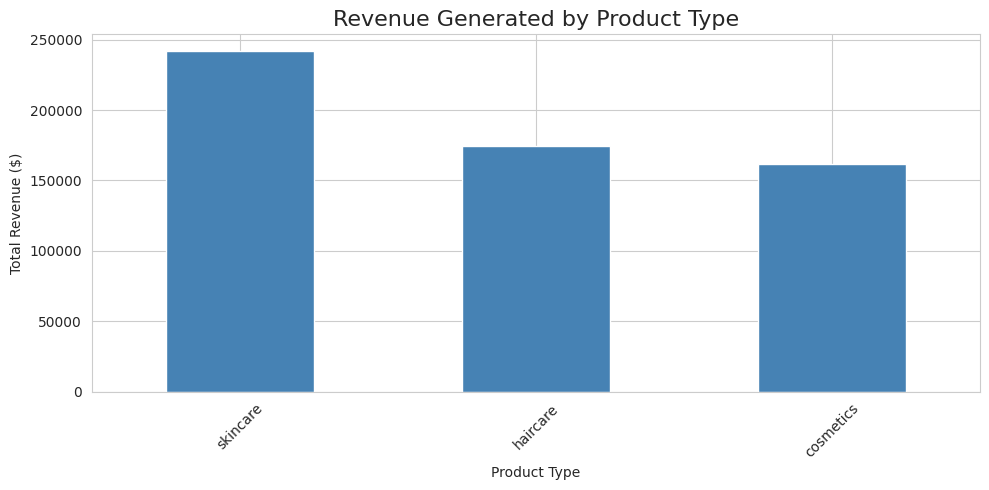

🏆 Top Product Type: skincare


In [5]:
revenue_by_product = df.groupby('Product_type')['Revenue_generated'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
revenue_by_product.plot(kind='bar', color='steelblue')
plt.title('Revenue Generated by Product Type', fontsize=16)
plt.xlabel('Product Type')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('revenue_by_product.png', dpi=150)
plt.show()

print("🏆 Top Product Type:", revenue_by_product.index[0])

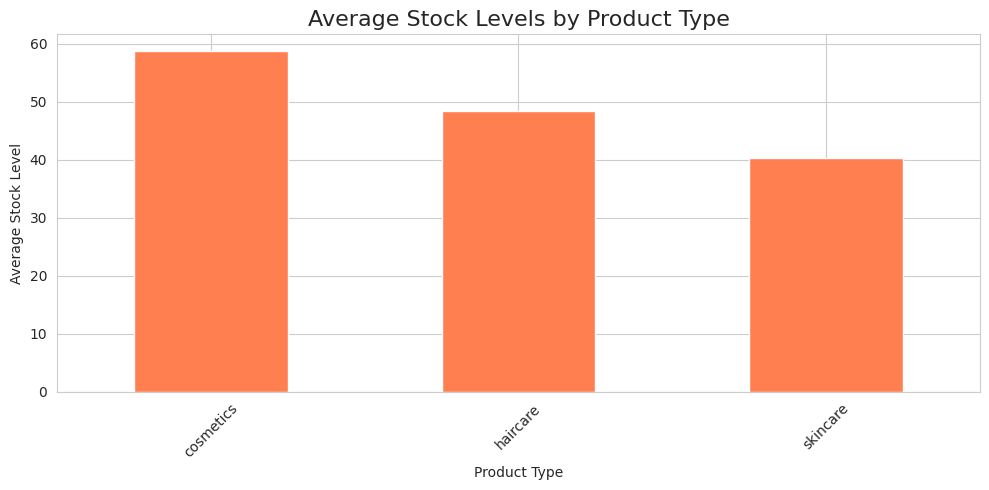

In [6]:
stock_by_product = df.groupby('Product_type')['Stock_levels'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
stock_by_product.plot(kind='bar', color='coral')
plt.title('Average Stock Levels by Product Type', fontsize=16)
plt.xlabel('Product Type')
plt.ylabel('Average Stock Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('stock_levels.png', dpi=150)
plt.show()

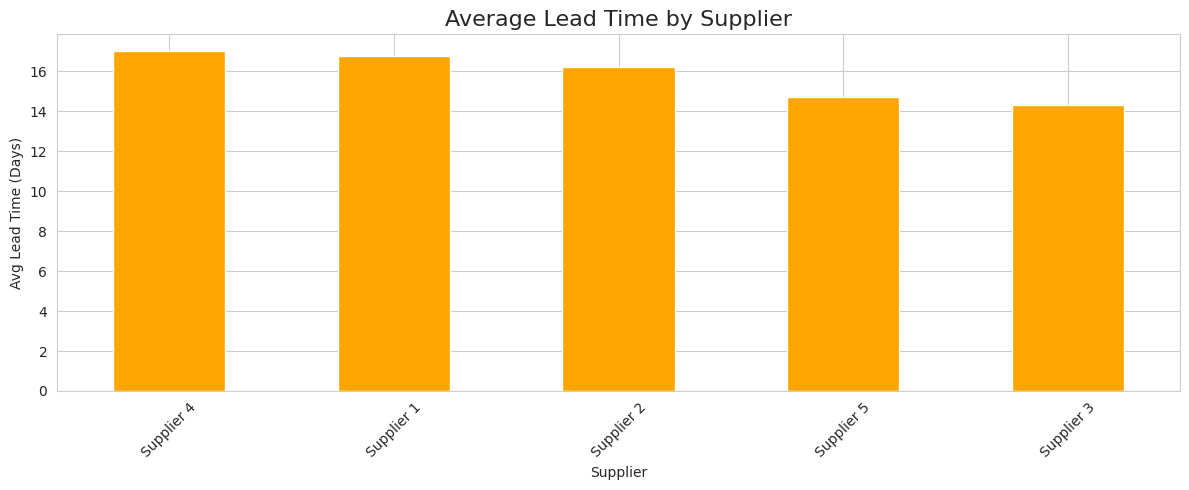

⚠️  Slowest Supplier: Supplier 4 → 17.0 days
✅ Fastest Supplier: Supplier 3 → 14.3 days


In [7]:
lead_time = df.groupby('Supplier_name')['Lead_times'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
lead_time.plot(kind='bar', color='orange')
plt.title('Average Lead Time by Supplier', fontsize=16)
plt.xlabel('Supplier')
plt.ylabel('Avg Lead Time (Days)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('supplier_lead_time.png', dpi=150)
plt.show()

print("⚠️  Slowest Supplier:", lead_time.index[0], "→", round(lead_time.iloc[0], 1), "days")
print("✅ Fastest Supplier:", lead_time.index[-1], "→", round(lead_time.iloc[-1], 1), "days")

📊 Stockout Risk Summary:
 Risk_Flag
🔴 High Risk      67
🟡 Medium Risk    17
🟢 Safe           16
Name: count, dtype: int64


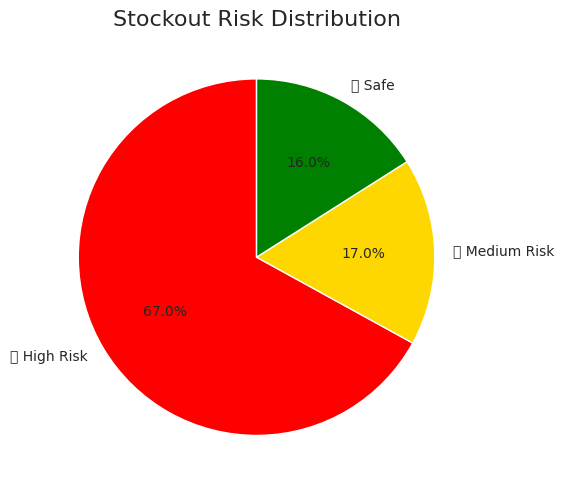

In [8]:
# Stockout risk = low stock + high sales volume
df['Stockout_Risk'] = df['Stock_levels'] / (df['Order_quantities'] + 1)

# Flag at-risk products
df['Risk_Flag'] = df['Stockout_Risk'].apply(
    lambda x: '🔴 High Risk' if x < 1.5 else ('🟡 Medium Risk' if x < 3 else '🟢 Safe')
)

risk_summary = df['Risk_Flag'].value_counts()
print("📊 Stockout Risk Summary:\n", risk_summary)

plt.figure(figsize=(7, 5))
plt.pie(risk_summary, labels=risk_summary.index,
        autopct='%1.1f%%',
        colors=['red', 'gold', 'green'],
        startangle=90)
plt.title('Stockout Risk Distribution', fontsize=16)
plt.tight_layout()
plt.savefig('stockout_risk.png', dpi=150)
plt.show()

In [9]:
# Reorder Point = Avg Daily Sales × Lead Time + Safety Stock
df['Avg_Daily_Sales']  = df['Number_of_products_sold'] / 30
df['Safety_Stock']     = df['Avg_Daily_Sales'] * 3  # 3-day buffer
df['Reorder_Point']    = (df['Avg_Daily_Sales'] * df['Lead_times'] + df['Safety_Stock']).round(2)
df['Needs_Reorder']    = df['Stock_levels'] <= df['Reorder_Point']

reorder_needed = df[df['Needs_Reorder'] == True][['SKU', 'Product_type',
                  'Stock_levels', 'Reorder_Point']].sort_values('Stock_levels')

print(f"⚠️  Products Needing Reorder: {reorder_needed.shape[0]}")
print("\nTop 10 Critical Products:")
reorder_needed.head(10)

⚠️  Products Needing Reorder: 89

Top 10 Critical Products:


,SKU,Product_type,Stock_levels,Reorder_Point
68,SKU68,haircare,0,59.77
2,SKU2,haircare,1,3.47
34,SKU34,skincare,1,581.93
16,SKU16,skincare,2,74.67
33,SKU33,cosmetics,4,410.67
47,SKU47,skincare,4,546.00
24,SKU24,haircare,4,202.03
4,SKU4,skincare,5,174.20
8,SKU8,cosmetics,5,65.00
57,SKU57,haircare,5,158.90


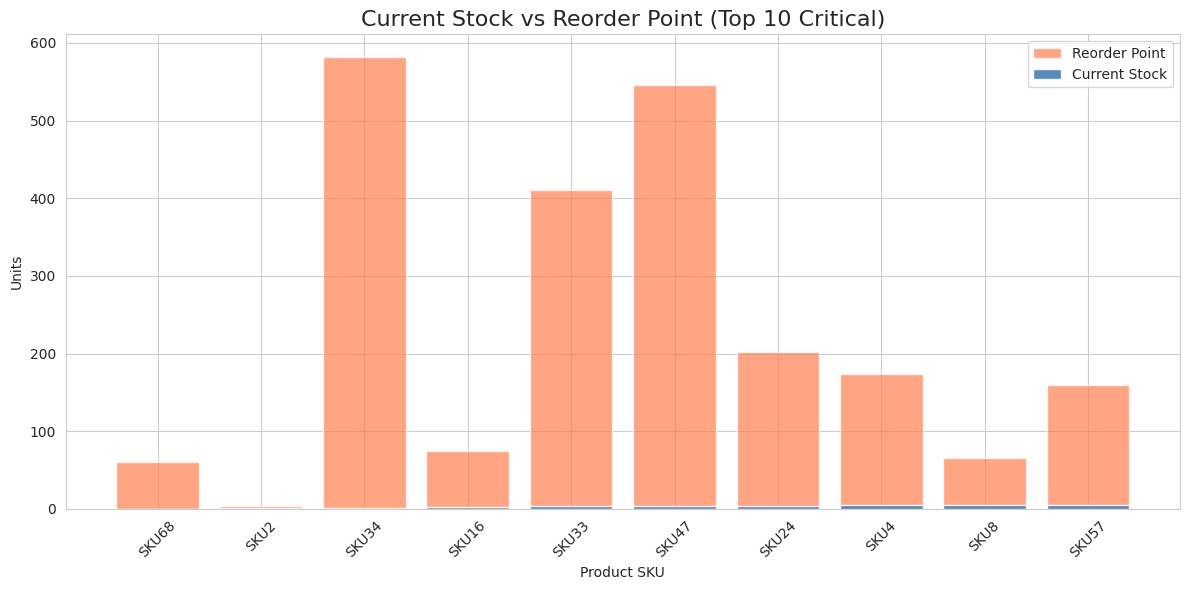

In [10]:
top_reorder = reorder_needed.head(10)

plt.figure(figsize=(12, 6))
x = range(len(top_reorder))
plt.bar(x, top_reorder['Reorder_Point'], color='coral',
        alpha=0.7, label='Reorder Point')
plt.bar(x, top_reorder['Stock_levels'], color='steelblue',
        alpha=0.9, label='Current Stock')
plt.xticks(x, top_reorder['SKU'], rotation=45)
plt.title('Current Stock vs Reorder Point (Top 10 Critical)', fontsize=16)
plt.xlabel('Product SKU')
plt.ylabel('Units')
plt.legend()
plt.tight_layout()
plt.savefig('reorder_urgency.png', dpi=150)
plt.show()

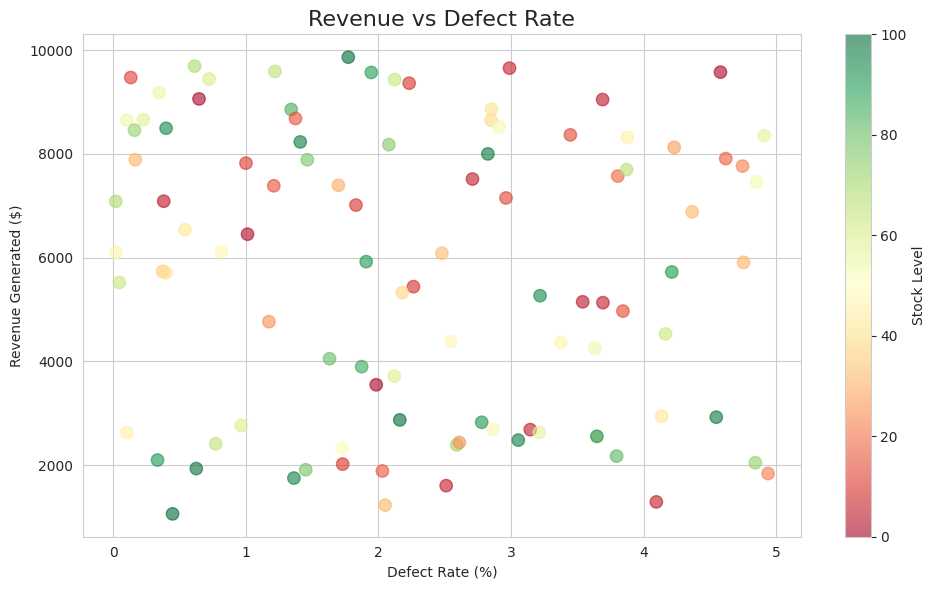

💡 Insight: High defect rates generally correlate with lower revenue


In [11]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Defect_rates'], df['Revenue_generated'],
                      c=df['Stock_levels'], cmap='RdYlGn',
                      alpha=0.6, s=80)
plt.colorbar(scatter, label='Stock Level')
plt.title('Revenue vs Defect Rate', fontsize=16)
plt.xlabel('Defect Rate (%)')
plt.ylabel('Revenue Generated ($)')
plt.tight_layout()
plt.savefig('revenue_vs_defect.png', dpi=150)
plt.show()

print("💡 Insight: High defect rates generally correlate with lower revenue")

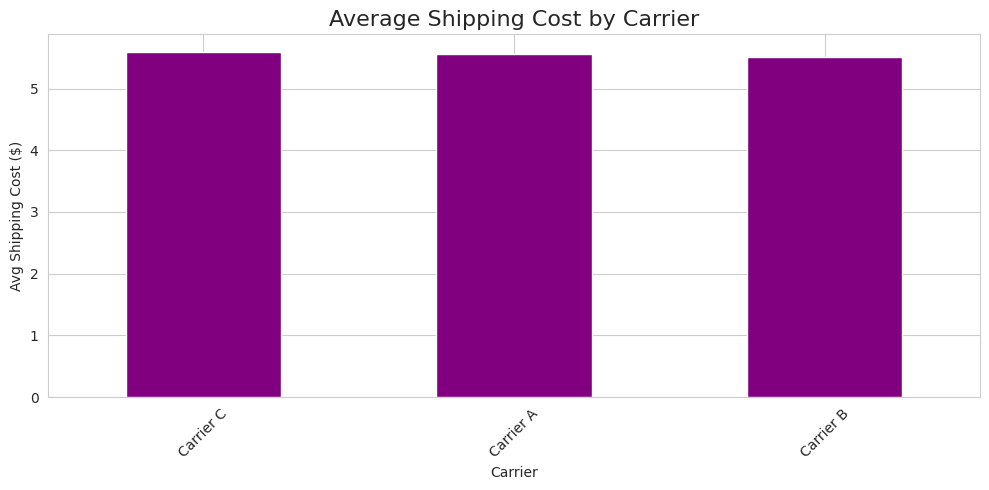

💰 Most Expensive Carrier: Carrier C
✅ Most Cost-Efficient Carrier: Carrier B


In [12]:
shipping = df.groupby('Shipping_carriers')['Shipping_costs'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
shipping.plot(kind='bar', color='purple')
plt.title('Average Shipping Cost by Carrier', fontsize=16)
plt.xlabel('Carrier')
plt.ylabel('Avg Shipping Cost ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('shipping_cost.png', dpi=150)
plt.show()

print("💰 Most Expensive Carrier:", shipping.index[0])
print("✅ Most Cost-Efficient Carrier:", shipping.index[-1])

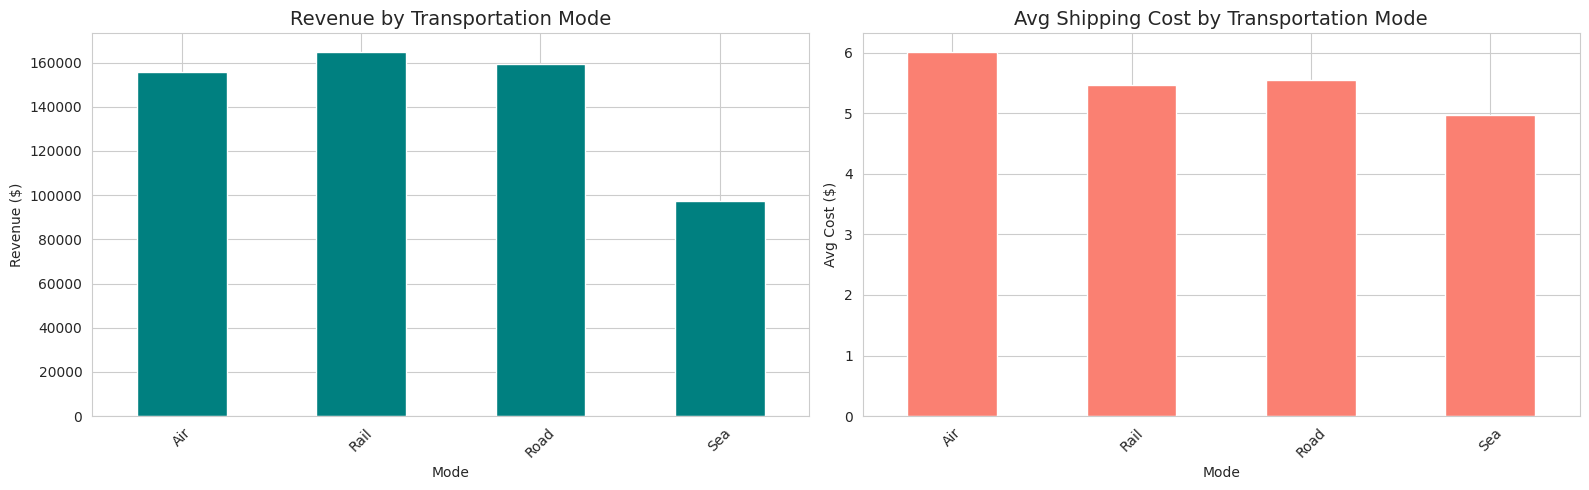

In [13]:
transport_revenue = df.groupby('Transportation_modes')['Revenue_generated'].sum()
transport_cost    = df.groupby('Transportation_modes')['Shipping_costs'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

transport_revenue.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Revenue by Transportation Mode', fontsize=14)
axes[0].set_xlabel('Mode')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

transport_cost.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Avg Shipping Cost by Transportation Mode', fontsize=14)
axes[1].set_xlabel('Mode')
axes[1].set_ylabel('Avg Cost ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('transportation_analysis.png', dpi=150)
plt.show()

In [14]:
print("=" * 55)
print("📦 SUPPLY CHAIN ANALYSIS — SUMMARY")
print("=" * 55)
print(f"\n📦 Total Products Analyzed  : {df.shape[0]:,}")
print(f"💰 Total Revenue            : ${df['Revenue_generated'].sum():,.2f}")
print(f"🏆 Top Product Type         : {revenue_by_product.index[0]}")
print(f"⚠️  Slowest Supplier         : {lead_time.index[0]} ({round(lead_time.iloc[0],1)} days)")
print(f"✅ Fastest Supplier          : {lead_time.index[-1]} ({round(lead_time.iloc[-1],1)} days)")
print(f"🔴 High Risk Products        : {(df['Risk_Flag']=='🔴 High Risk').sum()}")
print(f"📋 Products Needing Reorder  : {reorder_needed.shape[0]}")
print(f"💰 Most Efficient Carrier    : {shipping.index[-1]}")
print("=" * 55)

📦 SUPPLY CHAIN ANALYSIS — SUMMARY

📦 Total Products Analyzed  : 100
💰 Total Revenue            : $577,604.82
🏆 Top Product Type         : skincare
⚠️  Slowest Supplier         : Supplier 4 (17.0 days)
✅ Fastest Supplier          : Supplier 3 (14.3 days)
🔴 High Risk Products        : 67
📋 Products Needing Reorder  : 89
💰 Most Efficient Carrier    : Carrier B


In [15]:
import os
charts = ['revenue_by_product.png', 'stock_levels.png',
          'supplier_lead_time.png', 'stockout_risk.png',
          'reorder_urgency.png', 'revenue_vs_defect.png',
          'shipping_cost.png', 'transportation_analysis.png']

for chart in charts:
    if os.path.exists(chart):
        files.download(chart)

print("✅ All charts downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All charts downloaded!
